In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data" / "cleaned"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")

enrollment = pd.read_csv(DATA_DIR / "all_enrollment_combined.csv")
teachers = pd.read_csv(DATA_DIR / "total_trained_teachers_secondary_cleaned.csv")

In [7]:
secondary = pd.read_csv(DATA_DIR / "secondary_gender_merged.csv")
teachers = pd.read_csv(DATA_DIR / "total_trained_teachers_secondary_cleaned.csv")

In [8]:
merged = pd.merge(
    secondary,
    teachers,
    on=["country_code", "year"],
    how="inner"
)

In [10]:
merged["average_enrollment"] = (
    merged["male_enrollment"] + merged["female_enrollment"]
) / 2

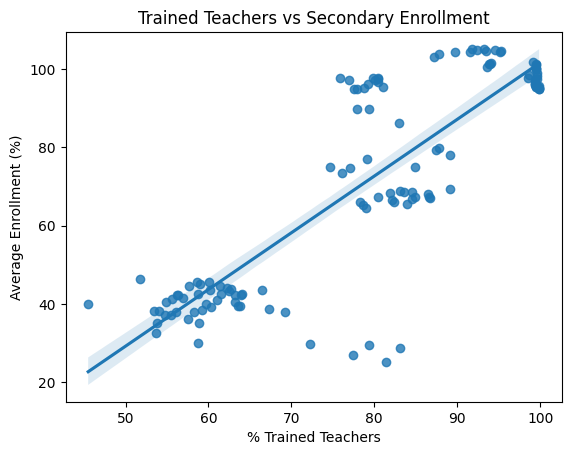

In [16]:
import seaborn as sns

sns.regplot(
    data=merged,
    x="trained_teacher",
    y="average_enrollment"
)

plt.title("Trained Teachers vs Secondary Enrollment")
plt.xlabel("% Trained Teachers")
plt.ylabel("Average Enrollment (%)")

save_fig("teachers_vs_enrollment")
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression

model_data = merged.dropna(subset=["trained_teacher", "female_enrollment"])

X = model_data[["trained_teacher"]]
y = model_data["female_enrollment"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: 1.5357803915077146
Intercept: -51.16996856997763
R^2: 0.7092462107707889


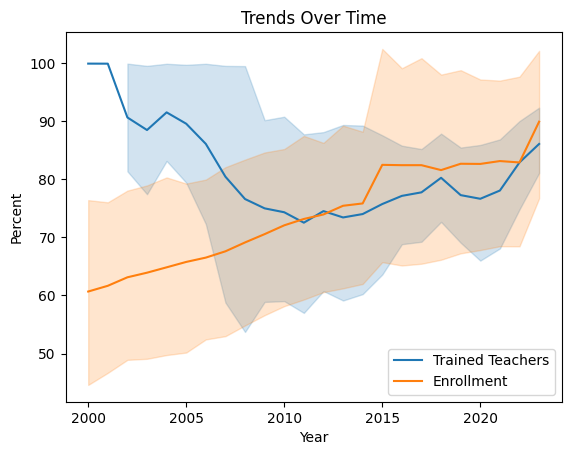

In [13]:
sns.lineplot(
    data=merged,
    x="year",
    y="trained_teacher",
    label="Trained Teachers"
)

sns.lineplot(
    data=merged,
    x="year",
    y="average_enrollment",
    label="Enrollment"
)

plt.title("Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Percent")

save_fig("time_trends")
plt.show()

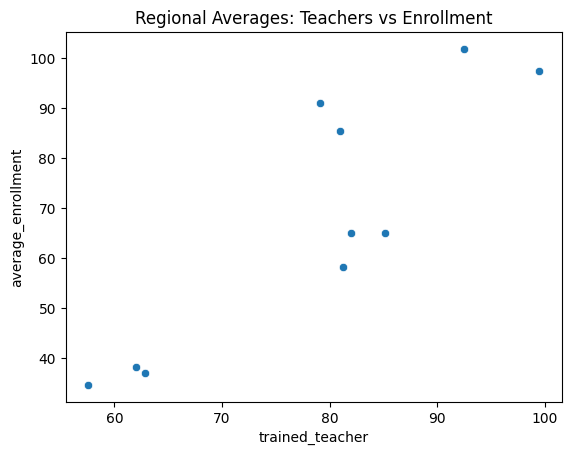

In [ ]:
region_avg = merged.groupby("country_name")[[
    "trained_teacher",
    "average_enrollment"
]].mean().reset_index()

sns.scatterplot(
    data=region_avg,
    x="trained_teacher",
    y="average_enrollment"
)

plt.title("Regional Averages: Teachers vs Enrollment")
plt.xlabel("% Trained Teachers")
plt.ylabel("Average Enrollment (%)")

save_fig("regional_scatter")
plt.show()

In [14]:
corr = merged[["trained_teacher", "average_enrollment"]].corr()
print(corr)

                    trained_teacher  average_enrollment
trained_teacher            1.000000            0.849116
average_enrollment         0.849116            1.000000


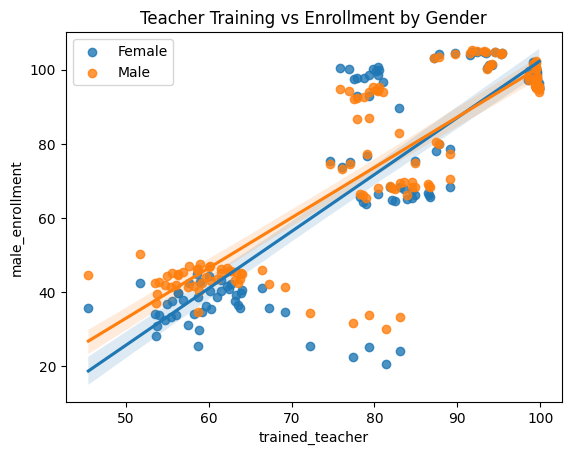

In [18]:
sns.regplot(
    data=merged,
    x="trained_teacher",
    y="female_enrollment",
    label="Female"
)

sns.regplot(
    data=merged,
    x="trained_teacher",
    y="male_enrollment",
    label="Male"
)

plt.legend()
plt.title("Teacher Training vs Enrollment by Gender")

save_fig("gender_comparison")
plt.show()

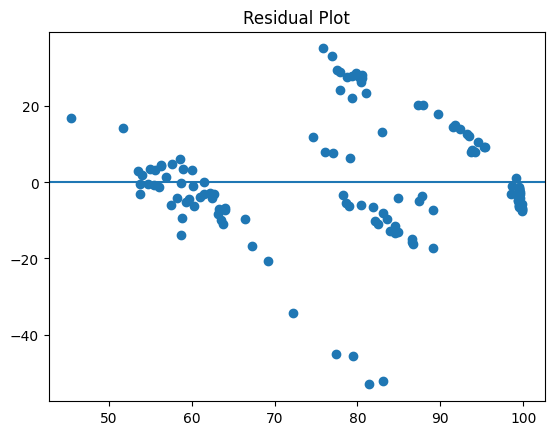

In [19]:
pred = model.predict(X)
residuals = y - pred

plt.scatter(X, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()